# 一、准备

## 1.库的导入

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import TwoSlopeNorm,LinearSegmentedColormap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import silhouette_score,roc_curve, auc,roc_auc_score, f1_score, classification_report, recall_score

## 2.字体设置

In [2]:
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
FONT_NAME = {'family':'SimHei'}

## 3.魔法命令

In [3]:
%matplotlib inline

## 4.导入用户特征宽表（MySQL中创建）

In [4]:
user_wide = pd.read_csv("olist_churn_retention/user_final_wide_table.csv")

# 二、探索性分析

## 1.用户总消费金额情况

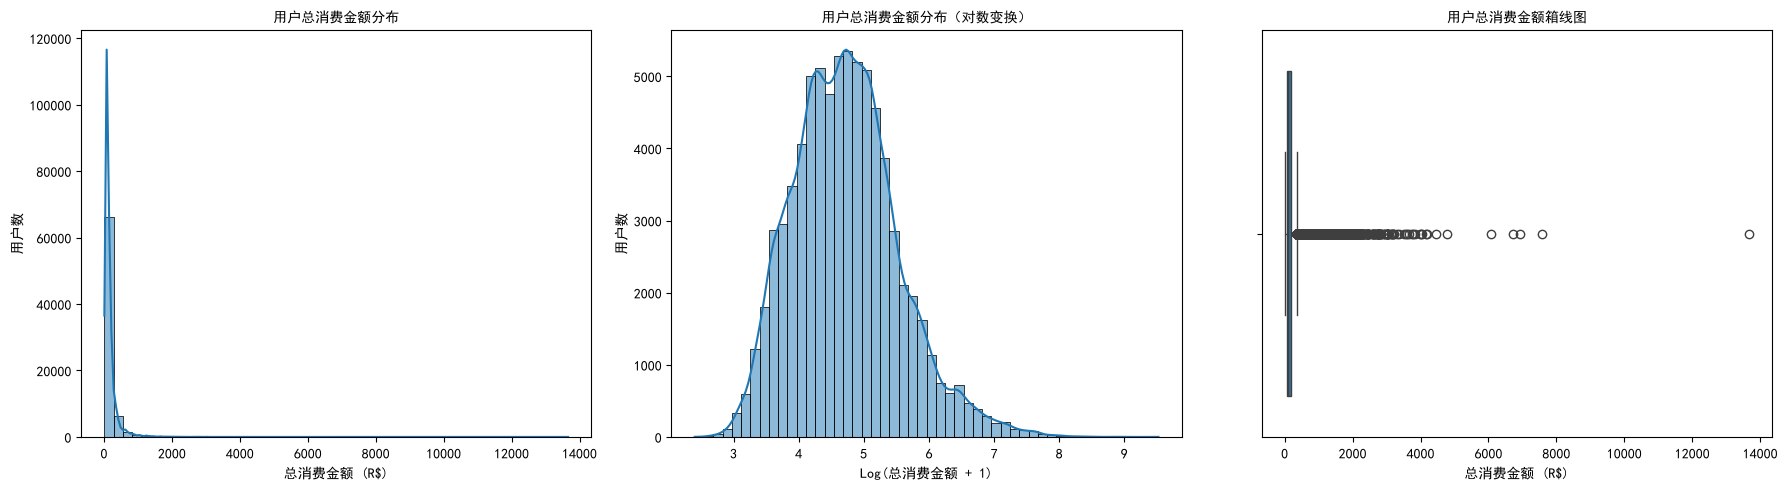

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图一：用户总消费金额分布（原始尺度）
ax1 = axes[0]
sns.histplot(user_wide['M'], bins=50, kde=True, ax=ax1)
ax1.set_title('用户总消费金额分布', fontproperties=FONT_NAME)
ax1.set_xlabel('总消费金额 (R$)', fontproperties=FONT_NAME)
ax1.set_ylabel('用户数', fontproperties=FONT_NAME)

# 图二：用户总消费金额分布（对数变换）
ax2 = axes[1]
log_revenue = np.log1p(user_wide['M'])
sns.histplot(log_revenue, bins=50, kde=True, ax=ax2)
ax2.set_title('用户总消费金额分布（对数变换）', fontproperties=FONT_NAME)
ax2.set_xlabel('Log(总消费金额 + 1)', fontproperties=FONT_NAME)
ax2.set_ylabel('用户数', fontproperties=FONT_NAME)

# 图三：用户总消费金额箱线图
ax3 = axes[2]
sns.boxplot(x=user_wide['M'], ax=ax3)
ax3.set_title('用户总消费金额箱线图', fontproperties=FONT_NAME)
ax3.set_xlabel('总消费金额 (R$)', fontproperties=FONT_NAME)

plt.tight_layout()
plt.show()

## 2.订单数分布情况（只看前10个）

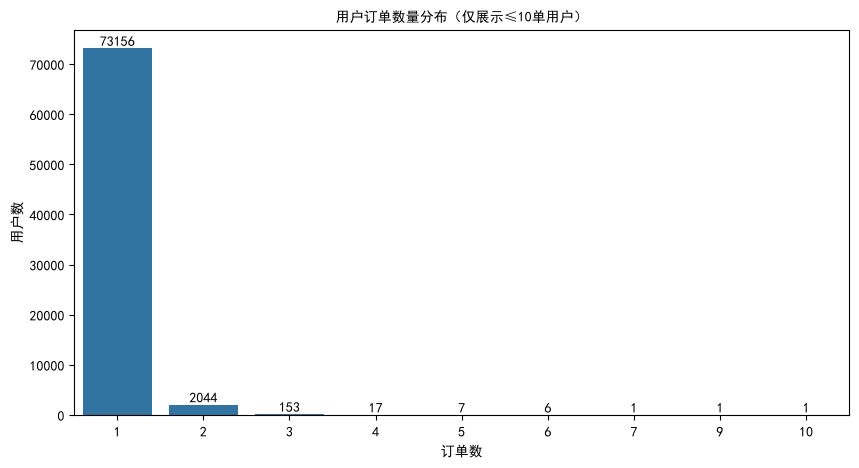

In [6]:
plt.figure(figsize=(10, 5))
user_wide_filtered = user_wide[user_wide['F'] <= 10]
order_counts = user_wide_filtered['F'].value_counts().sort_index()

sns.barplot(x=order_counts.index, y=order_counts.values)
plt.title('用户订单数量分布（仅展示≤10单用户）', fontproperties=FONT_NAME)
plt.xlabel('订单数', fontproperties=FONT_NAME)
plt.ylabel('用户数', fontproperties=FONT_NAME)
for i, v in enumerate(order_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

plt.show()

### 3.观测窗口内流失、留存与复购情况

观测窗口用户总数量：75386
用户整体流失率（预测窗口统计）：99.44%
观测窗口内历史复购率：2.96%


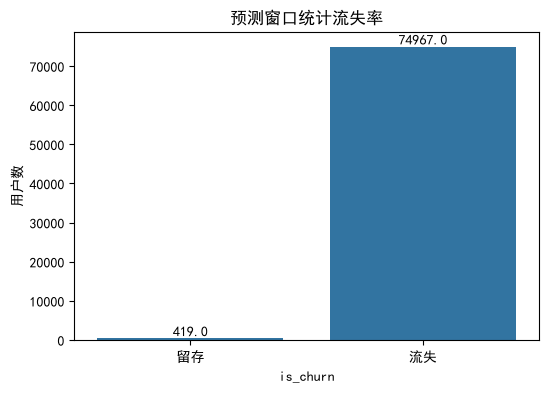

In [7]:
# 观测窗口用户，churn=1代表预测窗口流失
total_users = len(user_wide)
churn_rate = user_wide['is_churn'].mean()
#计算历史复购率
repurchase_rate = (user_wide['F'] >1).mean()

print(f"观测窗口用户总数量：{total_users}")
print(f"用户整体流失率（预测窗口统计）：{churn_rate:.2%}")
print(f"观测窗口内历史复购率：{repurchase_rate:.2%}")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_churn', data=user_wide)
plt.title('预测窗口统计流失率')
plt.xticks([0, 1], ['留存', '流失'])
plt.ylabel('用户数')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                xy=(p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

## 4.流失与留存用户的关键指标对比

               M             F        avg_order_value               R       
            mean  median  mean median            mean  median    mean median
is_churn                                                                    
0         169.24  114.38  1.17    1.0          139.35  102.03  160.54  131.0
1         164.42  107.17  1.03    1.0          157.11  103.11  195.87  178.0


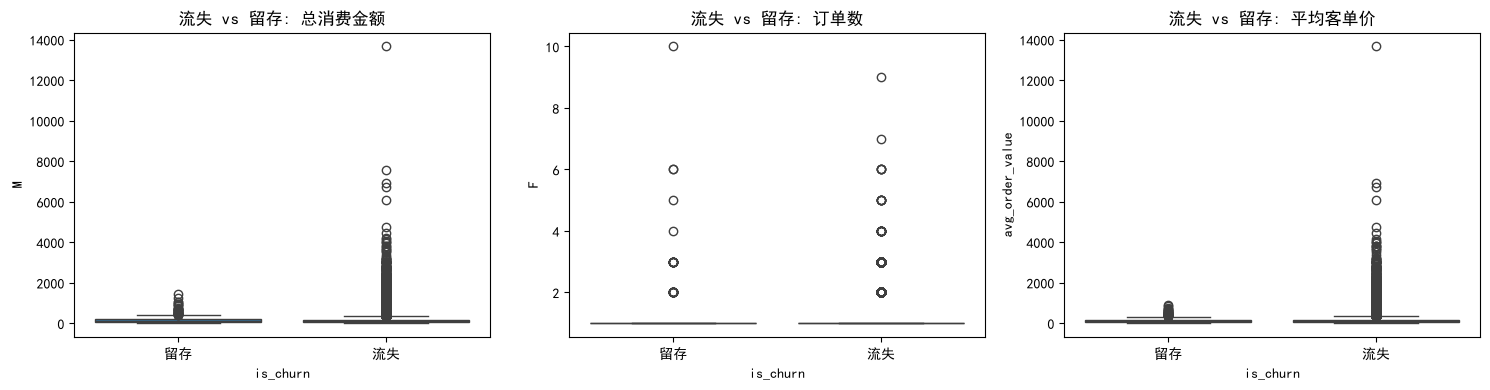

In [8]:
churn_comparison = user_wide.groupby('is_churn').agg({
    'M': ['mean', 'median'],
    'F': ['mean', 'median'],
    'avg_order_value': ['mean', 'median'],
    'R': ['mean', 'median']
}).round(2)

print(churn_comparison)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['M', 'F', 'avg_order_value']
titles = ['总消费金额', '订单数', '平均客单价']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.boxplot(x='is_churn', y=metric, data=user_wide, ax=axes[i])
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(['留存', '流失'])
    axes[i].set_title(f'流失 vs 留存: {title}')

plt.tight_layout()
plt.show()

## 5.查看特征相关性

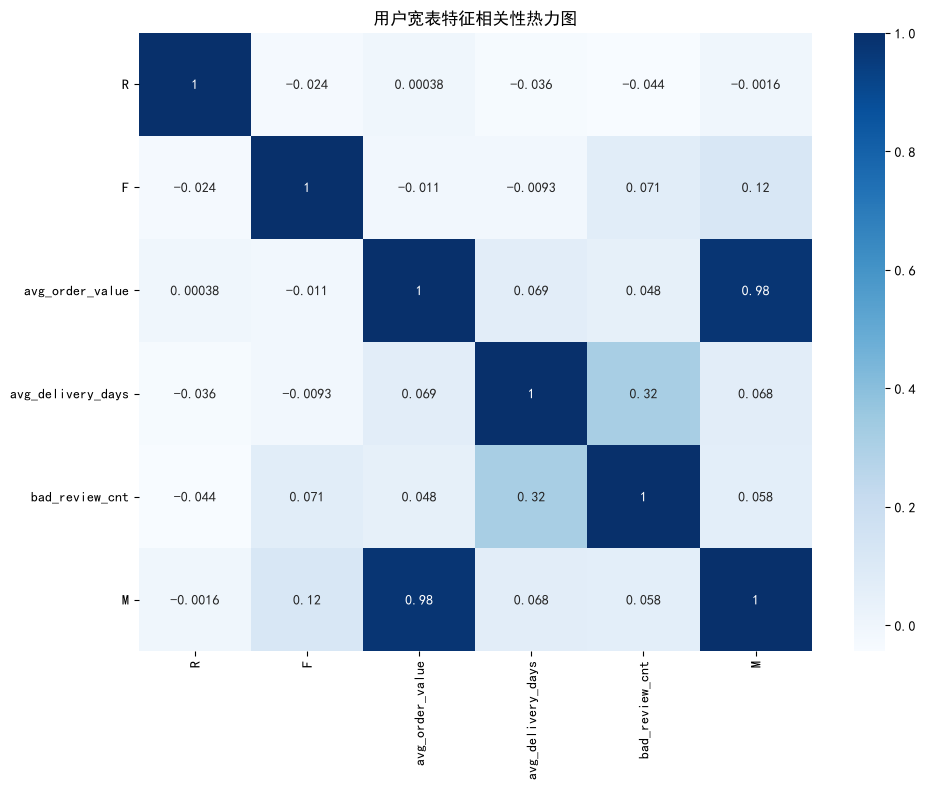

In [9]:
features_list__wide= [
    'R',
    'F',
    'avg_order_value',
    'avg_delivery_days',
    'bad_review_cnt',
    'M'
]

corr_matrix = user_wide[features_list__wide].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("用户宽表特征相关性热力图")
plt.tight_layout()

plt.show()

## 本次流失预测项目开展用户数据探索性分析。<br>用户消费金额呈严重右偏分布，经对数变换后近似正态；绝大多数用户仅产生 1 笔订单，复购基数极低。样本存在严重类别不平衡：总用户 75386 人，流失用户 74967 人，整体流失率高达 99.44%。<br>对比流失、留存两组用户特征：流失用户的最近一次消费间隔 R 值更高，总消费、订单数、客单价分布与留存用户差异有限。<br>相关性热力图显示，总消费金额 M 与平均客单价 avg_order_value 存在极强共线性；平均配送时长与差评数量存在中度正相关，其余特征间相关性偏弱。<br>后续建模需重点处理样本不均衡问题，剔除高度共线性特征，围绕用户消费间隔、差评、配送时效等维度构建流失预测模型。

# 三、RFM特征工程与标准化

In [10]:
#对F和M取对数调整长尾、对R取负 以适应模型逻辑
user_wide['neg_R'] = -user_wide['R'] 
user_wide['log_F'] = np.log1p(user_wide['F'])
user_wide['log_M'] = np.log1p(user_wide['M'])

In [11]:
cluster_features = user_wide[['neg_R','log_F','log_M']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)
scaled_user_wide = pd.DataFrame(scaled_features, columns=['neg_R','log_F','log_M'])
print("\n===== 标准化后的聚类特征 =====")
print(scaled_user_wide.head())


===== 标准化后的聚类特征 =====
      neg_R     log_F     log_M
0  0.050570 -0.169128  1.821786
1  0.921498 -0.169128 -0.838633
2 -1.736727 -0.169128  0.221229
3  1.375896 -0.169128 -0.559574
4  1.444055 -0.169128  2.066435


# 四、K-Means聚类

## 1.确定K值

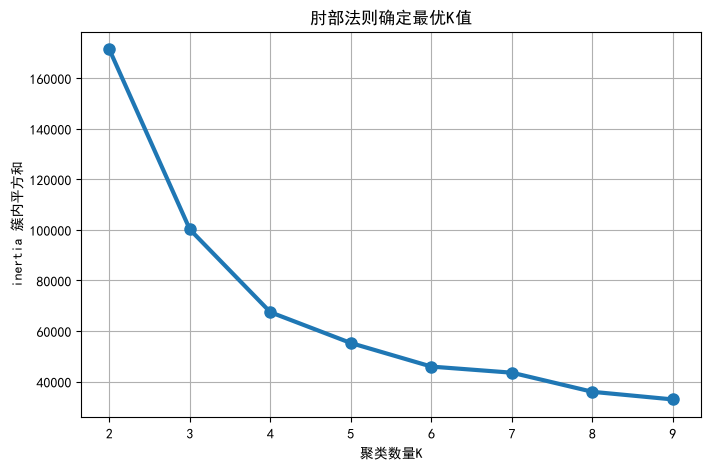

In [12]:
#肘部图
inertia_list = []
k_range = range(2,10)
for k in k_range:
    kms = KMeans(n_clusters=k, random_state=8, n_init='auto')
    kms.fit(scaled_features)
    inertia_list.append(kms.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia_list, marker='o', linewidth=3, markersize=8)
plt.xlabel('聚类数量K')
plt.ylabel('inertia 簇内平方和')
plt.title('肘部法则确定最优K值')
plt.grid(True)

plt.show()

K=2,轮廓系数：0.332
K=3,轮廓系数：0.386
K=4,轮廓系数：0.382
K=5,轮廓系数：0.362
K=6,轮廓系数：0.357
K=7,轮廓系数：0.357
K=8,轮廓系数：0.349
K=9,轮廓系数：0.345


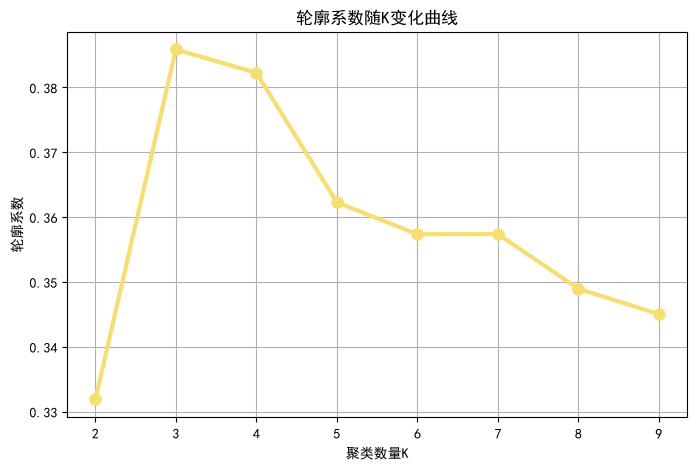

In [13]:
#轮廓系数
inertia_list = []
sil_list = []
k_range = range(2,10)

np.random.seed(8)
sample_idx = np.random.choice(scaled_features.shape[0], size=10000, replace=False)
scaled_sample = scaled_features[sample_idx]

for k in k_range:
    kms = KMeans(n_clusters=k, random_state=8, n_init='auto')
    kms.fit(scaled_features)
    inertia_list.append(kms.inertia_)
    
    cluster_label_sample = kms.predict(scaled_sample)
    sil_score = silhouette_score(scaled_sample, cluster_label_sample)
    sil_list.append(sil_score)
    print(f"K={k},轮廓系数：{sil_score:.3f}")

plt.figure(figsize=(8,5))
plt.plot(k_range, sil_list, marker='o', color="#F8DF6D", linewidth=3, markersize=8)
plt.xlabel('聚类数量K')
plt.ylabel('轮廓系数')
plt.title('轮廓系数随K变化曲线')
plt.grid(True)

plt.show()

## K从2增至4时，误差下降明显；K>4后边际收益趋缓，过拟合风险上升，K=4为拐点。<br>K=3时系数达到局部峰值，k=4的系数次之。<br>综合两种方法以及实际业务考虑，K=4，也就是将所有用户分为4类，是业务与统计平衡下的最佳选择。




## 2.聚类

In [14]:
k = 4
kms = KMeans(n_clusters=k, random_state=8, n_init='auto')
user_wide['cluster'] = kms.fit_predict(scaled_features)

print("\n===== 各簇用户数量 =====")
print(user_wide['cluster'].value_counts().sort_index())

cluster_profile = user_wide.groupby('cluster')[['R','F','M']].mean()
print("\n===== 聚类人群RFM原始均值画像 =====")
print(cluster_profile)

user_wide.to_csv("olist_churn_retention/olist_user_rfm_cluster.csv", index=False)


===== 各簇用户数量 =====
cluster
0    21949
1    29331
2    21876
3     2230
Name: count, dtype: int64

===== 聚类人群RFM原始均值画像 =====
                  R         F           M
cluster                                  
0        360.344161  1.000000  117.418836
1        114.906618  1.000000   70.887869
2        140.521622  1.000000  322.530111
3        178.369507  2.113004  307.150722


## 聚类画像结合业务为聚类打上业务标签：<br>聚类0：低价值沉睡用户<br>聚类1：低价值新用户<br>聚类2：高价值沉睡用户<br>聚类3：高价值复购用户

## 3.聚类效果评估

PC1解释方差: 38.9%
PC2解释方差: 33.2%
累计解释方差: 72.1%


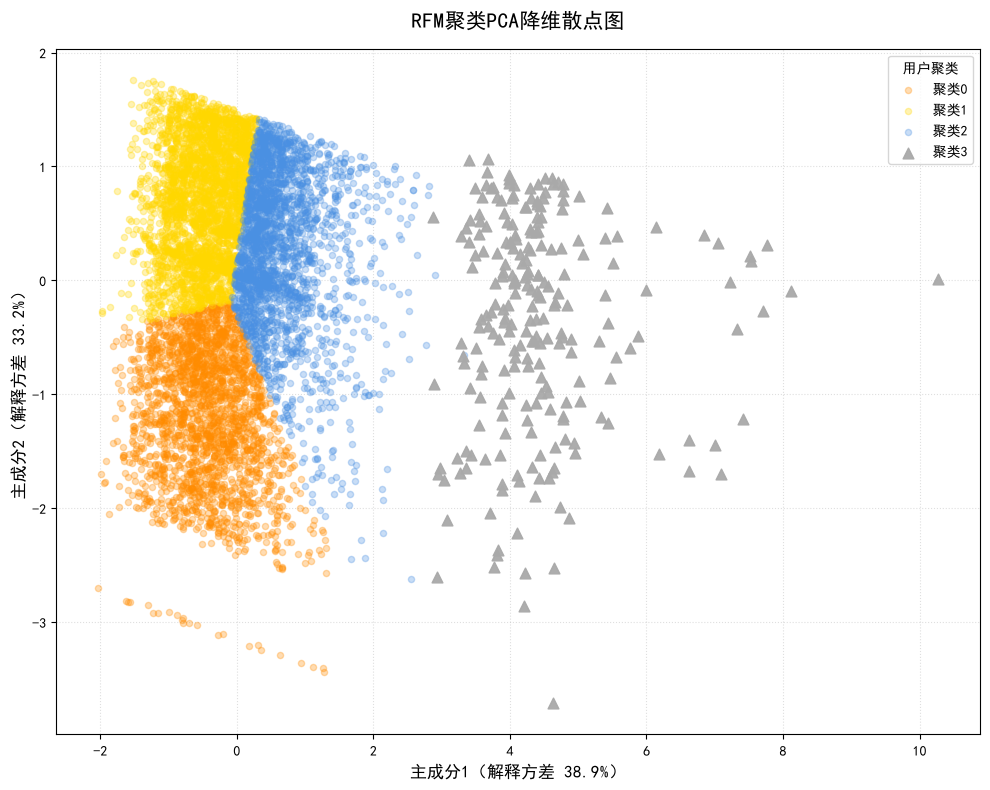

In [15]:
work = user_wide.copy() 
work['neg_R'] = -work['R']          
work['log_F'] = np.log1p(work['F'])  
work['log_M'] = np.log1p(work['M'])   
feat_cols = ['neg_R', 'log_F', 'log_M']
X_scaled = StandardScaler().fit_transform(work[feat_cols]) 

pca = PCA(n_components=2, random_state=42) #PCA降为2维
pcs = pca.fit_transform(X_scaled)
work["PC1"], work["PC2"] = pcs[:, 0], pcs[:, 1]
print(f"PC1解释方差: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2解释方差: {pca.explained_variance_ratio_[1]:.1%}")
print(f"累计解释方差: {pca.explained_variance_ratio_.sum():.1%}")

colors = {
    0: "#FF8C00",  
    1: "#FFD700", 
    2: "#4A90E2",  
    3: "#A9A9A9"  
}
plot_df = work.sample(n=min(8000, len(work)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 8))

for c in [0, 1, 2, 3]:
    sub = plot_df[plot_df["cluster"] == c]
    is_c3 = (c == 3)
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=60 if is_c3 else 20,
        marker="^" if is_c3 else "o",
        c=colors[c],
        alpha=0.95 if is_c3 else 0.3,
        zorder=6 if is_c3 else 3,
        label=f"聚类{c}"       
    )

ax.set_xlabel(f"主成分1（解释方差 {pca.explained_variance_ratio_[0]:.1%}）", fontsize=12)
ax.set_ylabel(f"主成分2（解释方差 {pca.explained_variance_ratio_[1]:.1%}）", fontsize=12)
ax.set_title("RFM聚类PCA降维散点图", fontsize=15, pad=15)
ax.legend(title="用户聚类")
ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

## 为验证K‑Means聚类结果的统计学有效性，我们使用PCA（主成分分析）将R、F、M三维特征投影至二维平面。<br>如上图所示，四类用户在降维空间中呈现出明显的分离趋势，累计方差解释率达72.1%，证明聚类结构在数学上显著成立。


# 五、流失预测模型

## 1.构建特征表

In [16]:
user_cluster = pd.read_csv("olist_churn_retention/olist_user_rfm_cluster.csv")
user_cluster['spend_per_day'] = user_cluster['M'] /( user_cluster['R']+1) #为避免inf保证完全相同的输入，公平对比，R加上1计算
features_list_cluster = [
    'R',
    'F',
    'avg_order_value',#为避免冗余与共线性剔除M，保留F与avg_order_value
    'avg_delivery_days',
    'bad_review_cnt',
    'spend_per_day',
    'cluster'#聚类标签作为特征之一训练模型
]

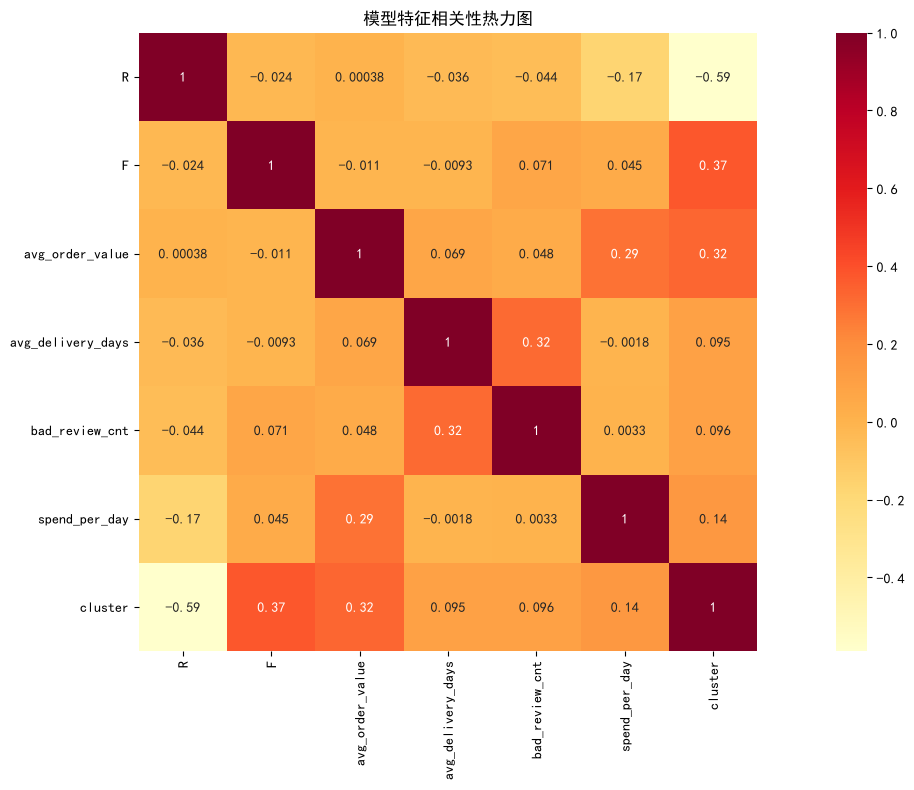

In [17]:
#查看特征表相关性
numeric_cols = user_cluster[features_list_cluster].select_dtypes(include='number').columns.tolist()
corr_matrix = user_cluster[numeric_cols].corr()

plt.figure(figsize=(16, 8))
sns.heatmap(
    corr_matrix,
    annot=True, 
    square=True,
    cmap='YlOrRd'        
)

plt.title('模型特征相关性热力图')
plt.tight_layout()
plt.show()

## 2.构建模型样本

In [18]:
##时序划分样本：观测窗口构建特征，预测窗口定义流失标签，规避时间泄露并按 8:2 分层抽样划分训练集与测试集

X= user_cluster[features_list_cluster]
y = user_cluster['is_churn']

X = pd.get_dummies(X, columns=['cluster'], prefix='cluster')
final_features = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=8,
    stratify=y
)

## 3.流失预测模型

### XGBoost模型

In [19]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    scale_pos_weight=1, #模型未加权，设定为默认值1
    learning_rate=0.05,
    random_state=8,
    eval_metric="auc",
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(X_train, y_train)

y_pred_proba = xgb_model.predict_proba(X_test)[:,1]
y_pred = xgb_model.predict(X_test)

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\n测试集 AUC = {auc_score:.4f}")
print("===== XGBoost 测试集分类报告 =====")
print(classification_report(y_test, y_pred, target_names=['留存用户(0)', '流失用户(1)'],zero_division=0))


测试集 AUC = 0.6253
===== XGBoost 测试集分类报告 =====
              precision    recall  f1-score   support

     留存用户(0)       0.00      0.00      0.00        84
     流失用户(1)       0.99      1.00      1.00     14994

    accuracy                           0.99     15078
   macro avg       0.50      0.50      0.50     15078
weighted avg       0.99      0.99      0.99     15078



### 逻辑回归模型

In [20]:
num_cols = ['R', 'F', 'avg_order_value', 'avg_delivery_days',
            'bad_review_cnt', 'spend_per_day']
lr_preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols)
], remainder="passthrough") 

lr_model = Pipeline([
    ("preprocess", lr_preprocess),
    ("lr", LogisticRegression(max_iter=1000, random_state=8))
])

lr_model.fit(X_train, y_train)

lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = lr_model.predict(X_test)

lr_auc = roc_auc_score(y_test, lr_pred_proba)
print(f"逻辑回归 测试集AUC = {lr_auc:.4f}")      # 定稿口径≈0.6309
print(classification_report(y_test, lr_pred,target_names=['留存用户(0)', '流失用户(1)']))

逻辑回归 测试集AUC = 0.6309
              precision    recall  f1-score   support

     留存用户(0)       0.50      0.01      0.02        84
     流失用户(1)       0.99      1.00      1.00     14994

    accuracy                           0.99     15078
   macro avg       0.75      0.51      0.51     15078
weighted avg       0.99      0.99      0.99     15078



### 模型对比

In [21]:
#重要指标对比
xgb_f1 = f1_score(y_test, y_pred, average='macro')
lr_f1  = f1_score(y_test, lr_pred, average='macro')

def lift_at_k(y_true, proba, k):
    n = int(len(y_true) * k)
    order = np.argsort(-proba)               
    top_y = np.asarray(y_true)[order][:n]
    return top_y.mean() / np.asarray(y_true).mean()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
xgb_cv = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
lr_cv  = cross_val_score(lr_model,  X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

compare = pd.DataFrame({
    '留出AUC':      [auc_score, lr_auc],
    'Macro-F1':     [xgb_f1, lr_f1],
    'Lift@Top10%':  [lift_at_k(y_test, y_pred_proba, .1), lift_at_k(y_test, lr_pred_proba, .1)],
    'Lift@Top20%':  [lift_at_k(y_test, y_pred_proba, .2), lift_at_k(y_test, lr_pred_proba, .2)],
    'Lift@Top30%':  [lift_at_k(y_test, y_pred_proba, .3), lift_at_k(y_test, lr_pred_proba, .3)],
    '5折AUC均值':   [xgb_cv.mean(), lr_cv.mean()],
    '5折AUC标准差': [xgb_cv.std(),  lr_cv.std()]
}, index=['XGBoost', '逻辑回归']).round(4)

print("===== XGBoost(depth=3) vs 逻辑回归 对比表 =====")
print(compare)

===== XGBoost(depth=3) vs 逻辑回归 对比表 =====
          留出AUC  Macro-F1  Lift@Top10%  Lift@Top20%  Lift@Top30%  5折AUC均值  \
XGBoost  0.6253    0.4986       1.0029       1.0029       1.0025   0.5772   
逻辑回归     0.6309    0.5102       0.9996       1.0016       1.0020   0.6012   

         5折AUC标准差  
XGBoost    0.0342  
逻辑回归       0.0391  


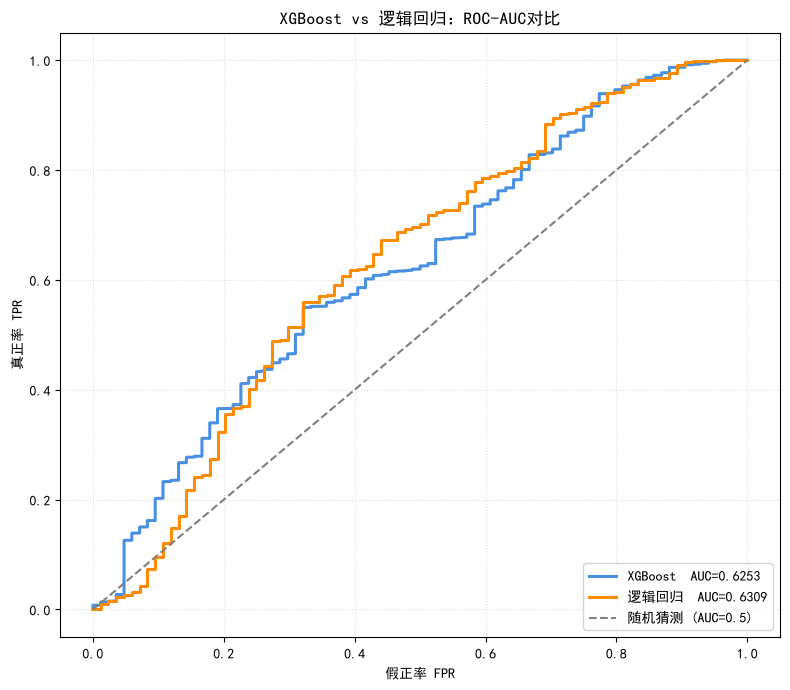

In [22]:
#ROC-AUC对比曲线图
fpr_x, tpr_x, _ = roc_curve(y_test, y_pred_proba)
fpr_l, tpr_l, _ = roc_curve(y_test, lr_pred_proba)

plt.figure(figsize=(8, 7))
plt.plot(fpr_x, tpr_x, lw=2.2, color="#4A90E2", label=f"XGBoost  AUC={auc_score:.4f}")
plt.plot(fpr_l, tpr_l, lw=2.2, color="#FF8C00", label=f"逻辑回归  AUC={lr_auc:.4f}")
plt.plot([0, 1], [0, 1], ls="--", c="gray", label="随机猜测 (AUC=0.5)")
plt.xlabel("假正率 FPR"); plt.ylabel("真正率 TPR")
plt.title("XGBoost vs 逻辑回归：ROC-AUC对比")
plt.legend(loc="lower right"); plt.grid(ls=":", alpha=.4)
plt.tight_layout()
plt.show()

## XGBoost与逻辑回归的留出测试集AUC分别为0.6253、0.6309，5折交叉验证AUC差距小于一倍标准差，ROC曲线几乎重合；<br>Lift方面XGBoost在Top10%、Top20%高风险人群上略优，Macro-F1逻辑回归略高两模型互有高低、整体性能相当，不存在显著优劣。<br>在效果等价的前提下，最终选用XGBoost，逻辑回归作为线性基准。



===== XGB特征重要性 =====
             feature  importance
1                  F    0.232952
9          cluster_3    0.202778
0                  R    0.105052
5      spend_per_day    0.103925
3  avg_delivery_days    0.090657
2    avg_order_value    0.085968
4     bad_review_cnt    0.064036
7          cluster_1    0.063863
8          cluster_2    0.050769
6          cluster_0    0.000000


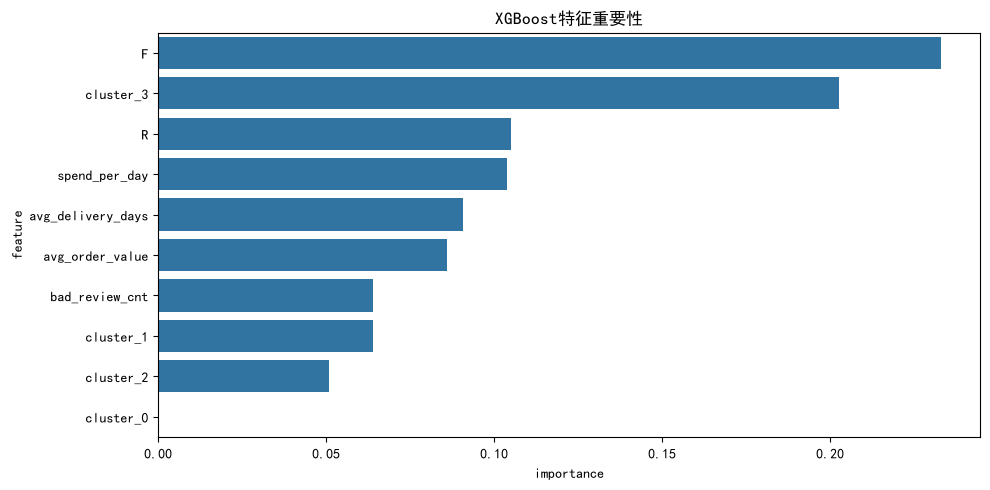

In [23]:
#XGBoost特征重要性
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\n===== XGB特征重要性 =====")
print(feature_importance)

plt.figure(figsize=(10,5))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('XGBoost特征重要性')
plt.tight_layout()
plt.show()

### 消费频次F（23.3%）与高价值复购人群标签cluster_3（20.3%）贡献最高，用户历史消费惯性与价值分层是流失的核心驱动；<br>最近消费间隔R（10.5%）与日均消费额（10.4%）构成第二梯队，消费节奏放缓是流失的直接先兆。<br>配送时长、客单价、差评数提供辅助信号，说明履约体验亦影响留存。<br>聚类标签合计贡献约31.8%，验证了"RFM分群+流失预测"组合建模的有效性。<br>结论：运营应重点盯防高价值客群的频次下降与活跃间隔拉长，并辅以物流、差评的体验干预。




## 4.补充：模型设计的消融实验

### 消融实验一：聚类标签cluster不作为训练模型的特征

In [24]:
cluster_cols = [c for c in X.columns if c.startswith('cluster_')]
X_no_cluster = X.drop(columns=cluster_cols)

Xtr_nc, Xte_nc, ytr_nc, yte_nc = train_test_split(
    X_no_cluster, y, test_size=0.2, random_state=8, stratify=y
)

xgb_no_cluster = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=1,            # 不加权重
    random_state=8, eval_metric="auc"
)
xgb_no_cluster.fit(Xtr_nc, ytr_nc)
proba_nc = xgb_no_cluster.predict_proba(Xte_nc)[:, 1]
pred_nc = xgb_no_cluster.predict(Xte_nc)

print("不含cluster:AUC =", round(roc_auc_score(yte_nc, proba_nc), 4),
      " Macro-F1 =", round(f1_score(yte_nc, pred_nc, average='macro'), 4))
print(f"\n含cluster的测试集 AUC = {auc_score:.4f}")  #上面跑的含cluster的AUC

 #聚类标签cluster特征消融实验 验证cluster无泄漏，对逻辑回归非线性补充

不含cluster:AUC = 0.611  Macro-F1 = 0.4986

含cluster的测试集 AUC = 0.6253


### 含cluster的测试集 AUC = 0.6253 > 不含cluster:AUC = 0.611<br>故基准模型特征表包含cluster，聚类标签观测窗口生成、无泄露；经消融实验保留，对LR是非线性补充

### 消融实验二：模型训练是否加权

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
spw = (y_train == 0).sum() / (y_train == 1).sum()   # 权重约0.01

for name, w in [("不加权", 1), ("加权重", spw)]:
    model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=w, random_state=8, eval_metric="auc")
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    cv_auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)

    print(f"===== {name} (scale_pos_weight={w:.3f}) =====")
    print("留出AUC=", round(roc_auc_score(y_test, proba), 4))
    print("5折AUC=", round(cv_auc.mean(), 4), "±", round(cv_auc.std(), 4))
    print("Macro-F1=", round(f1_score(y_test, pred, average="macro"), 4))
    print("流失类召回率=", round(recall_score(y_test, pred, pos_label=1), 4))
    print()

===== 不加权 (scale_pos_weight=1.000) =====
留出AUC= 0.6253
5折AUC= 0.5772 ± 0.0342
Macro-F1= 0.4986
流失类召回率= 1.0

===== 加权重 (scale_pos_weight=0.006) =====
留出AUC= 0.6264
5折AUC= 0.5813 ± 0.0377
Macro-F1= 0.4374
流失类召回率= 0.7546



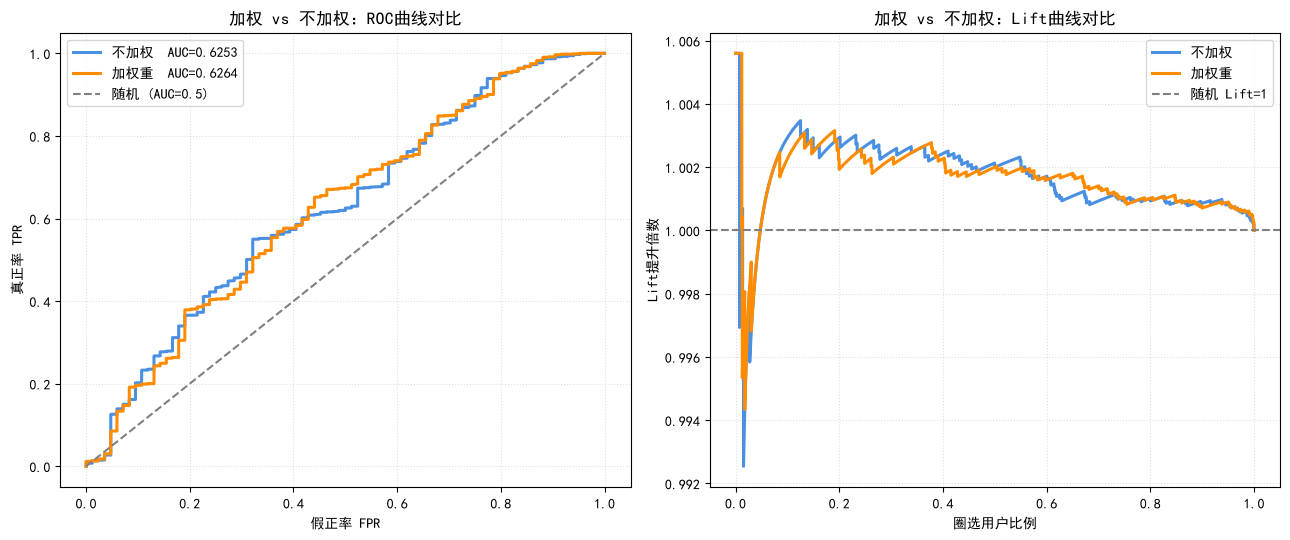

In [26]:
#实验二ROC与Lift曲线对比
prob_dict, auc_dict = {}, {}
for name, w, color in [("不加权", 1, "#4A90E2"), ("加权重", spw, "#FF8C00")]:
    model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=w, random_state=8, eval_metric="auc")
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    prob_dict[name] = p
    auc_dict[name] = roc_auc_score(y_test, p)

def lift_curve(y_true, proba):
    order = np.argsort(-proba)             
    yt = np.asarray(y_true)[order]
    pop = np.arange(1, len(yt) + 1) / len(yt)
    top_rate = np.cumsum(yt) / np.arange(1, len(yt) + 1) 
    lift = top_rate / yt.mean()       
    return pop, lift

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
colors = {"不加权": "#4A90E2", "加权重": "#FF8C00"}


for name in ["不加权", "加权重"]:
    fpr, tpr, _ = roc_curve(y_test, prob_dict[name])
    ax[0].plot(fpr, tpr, lw=2.2, color=colors[name],
               label=f"{name}  AUC={auc_dict[name]:.4f}")
ax[0].plot([0, 1], [0, 1], ls="--", c="gray", label="随机 (AUC=0.5)")
ax[0].set(xlabel="假正率 FPR", ylabel="真正率 TPR", title="加权 vs 不加权：ROC曲线对比")
ax[0].legend(); ax[0].grid(ls=":", alpha=.4)


for name in ["不加权", "加权重"]:
    pop, lift = lift_curve(y_test, prob_dict[name])
    ax[1].plot(pop, lift, lw=2.2, color=colors[name], label=name)
ax[1].axhline(1, ls="--", c="gray", label="随机 Lift=1")
ax[1].set(xlabel="圈选用户比例", ylabel="Lift提升倍数", title="加权 vs 不加权：Lift曲线对比")
ax[1].legend(); ax[1].grid(ls=":", alpha=.4)

plt.tight_layout()
plt.show()

### 两种设置的留出AUC与5折AUC几乎一致，差异均小于一倍标准差，说明类别权重不改变模型排序能力；但加权后Macro-F1由0.4986降至0.4374，流失用户召回率由100%降至75.46%，即漏掉约25%本应挽留的高风险用户。<br>本数据正类（流失）为绝对多数类，加权会使模型过度迎合仅0.56%的留存样本、与"尽量完整识别待挽留用户"的业务目标相悖，故最终不使用类别权重


## 5.业务有效性评估

In [27]:
#取出目标客群：聚类2和聚类3用户
target_cluster = user_cluster[user_cluster['cluster'].isin([2, 3])].copy()
Xt = pd.get_dummies(target_cluster[features_list_cluster], columns=['cluster'], prefix='cluster')
Xt = Xt.replace([np.inf, -np.inf], np.nan).reindex(columns=X.columns, fill_value=0)
yt = target_cluster['is_churn'].values

xgb_p = xgb_model.predict_proba(Xt)[:, 1]  
lr_p  = lr_model.predict_proba(Xt)[:, 1]  
colors = {"XGBoost": "#4A90E2", "逻辑回归": "#FF8C00"}

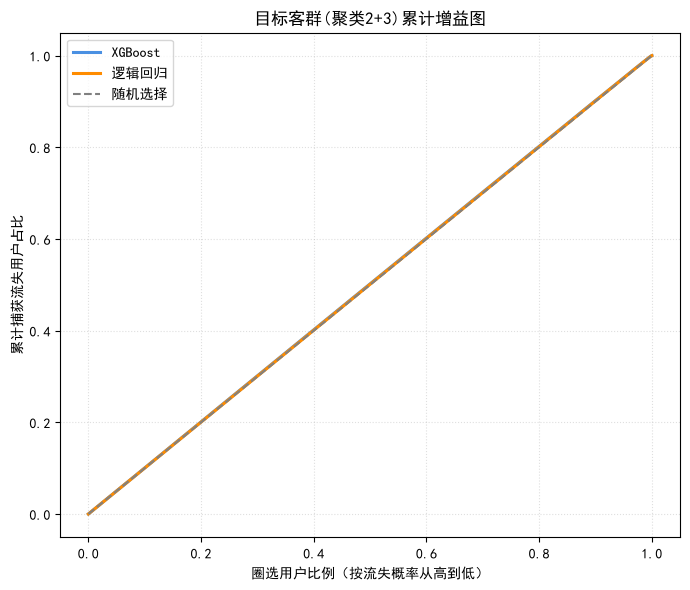

In [28]:
#目标客群累计增益图
def gain_curve(y, p):
    order = np.argsort(-p)
    yt = np.asarray(y)[order]
    pop = np.arange(1, len(yt) + 1) / len(yt)     
    gain = np.cumsum(yt) / yt.sum()              
    return pop, gain

plt.figure(figsize=(7, 6))
for name, p in [("XGBoost", xgb_p), ("逻辑回归", lr_p)]:
    pop, gain = gain_curve(yt, p)
    plt.plot(pop, gain, lw=2.2, color=colors[name], label=name)
plt.plot([0, 1], [0, 1], ls="--", c="gray", label="随机选择")
plt.xlabel("圈选用户比例（按流失概率从高到低）")
plt.ylabel("累计捕获流失用户占比")
plt.title("目标客群(聚类2+3)累计增益图")
plt.legend(); plt.grid(ls=":", alpha=.4); plt.tight_layout()
plt.show()

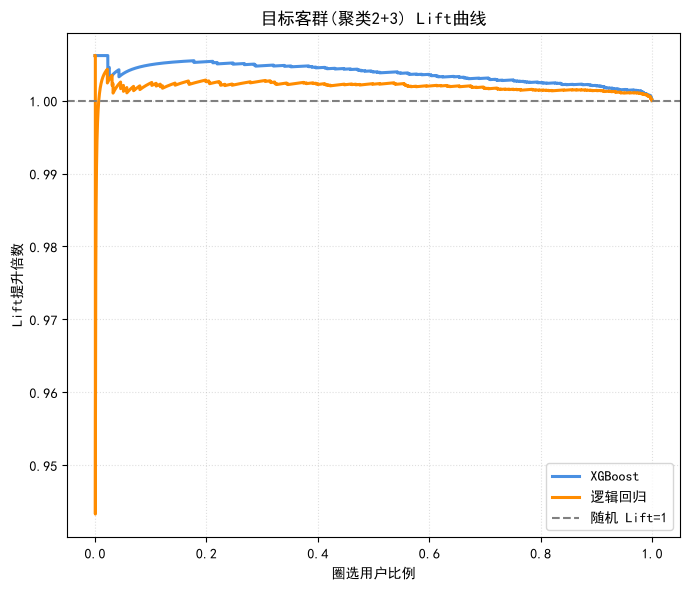

In [29]:
#目标客群Lift曲线
def lift_curve(y, p):
    order = np.argsort(-p)
    yt = np.asarray(y)[order]
    pop = np.arange(1, len(yt) + 1) / len(yt)
    top_rate = np.cumsum(yt) / np.arange(1, len(yt) + 1)
    lift = top_rate / yt.mean()                   # Top人群流失率/整体流失率
    return pop, lift

plt.figure(figsize=(7, 6))
for name, p in [("XGBoost", xgb_p), ("逻辑回归", lr_p)]:
    pop, lift = lift_curve(yt, p)
    plt.plot(pop, lift, lw=2.2, color=colors[name], label=name)
plt.axhline(1, ls="--", c="gray", label="随机 Lift=1")
plt.xlabel("圈选用户比例")
plt.ylabel("Lift提升倍数")
plt.title("目标客群(聚类2+3) Lift曲线")
plt.legend(); plt.grid(ls=":", alpha=.4); plt.tight_layout()
plt.show()

In [30]:
#全量内AUC vs 目标客群内AUC
xgb_auc_all = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
lr_auc_all  = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])

xgb_auc_t = roc_auc_score(yt, xgb_p)
lr_auc_t  = roc_auc_score(yt, lr_p)

print(f"全量人群:XGBoost={xgb_auc_all:.4f} | 逻辑回归={lr_auc_all:.4f}")
print(f"目标客群2/3:XGBoost={xgb_auc_t:.4f} | 逻辑回归={lr_auc_t:.4f}")

全量人群:XGBoost=0.6253 | 逻辑回归=0.6309
目标客群2/3:XGBoost=0.7499 | 逻辑回归=0.6422


## 营销仅触达聚类2/3，故客群内AUC才是决策依据。<br>XGBoost由全量0.6253提升至0.7499，并以0.108的优势反超逻辑回归，模型在真实投放人群中具备稳定排序能力，验证了模型选型。<br>累计增益图按流失概率降序圈选，Top30%可覆盖30.14%的潜在流失者、方向优于随机；<br>Lift稳定在1.005左右（Top20%达1.0053），略优于随机；<br>由于客群流失率高达99.39%（随机基线即≈99.4%），累计增益曲线极其贴近对角线并且Lift趋稳，非模型失效，属高基数下的数学必然。


# 六、挽留策略ROI测算

## 1.挽留策略ROI

In [31]:
#参数假设
THRESHOLD_AOV   = 67     #盈亏平衡客单价 = 券面额/毛利率 = 10/15%
GROSS_MARGIN    = 0.15   #毛利率
COUPON_DISCOUNT = 10     #优惠券成本（满100减10）
TARGET_AOV      = 160    #被挽回客单价：40%凑单100 + 60%历史客单200 加权
REDEMPTION_RATE = 0.06   #核销率
CHURN_REDUCTION = 0.50   #挽回率（核销者中因券回流的增量占比）
TOP_RATIO       = 0.30   #筛选目标客群内流失率最高的前30%

In [32]:
#筛选优惠券触达人群

#一级筛选见业务有效性评估 得到target_cluster代表聚类2和聚类3的高价值用户
#二级筛选 历史客单价大于67的用户 财务保本
target_avg = target_cluster[target_cluster['avg_order_value'] >= THRESHOLD_AOV] 
#三级筛选流失率前30%
Xt = pd.get_dummies(target_avg[features_list_cluster], columns=['cluster'], prefix='cluster')
Xt = Xt.replace([np.inf, -np.inf], np.nan).reindex(columns=X.columns, fill_value=0)
target_avg['churn_proba'] = xgb_model.predict_proba(Xt)[:, 1]
cut = target_avg['churn_proba'].quantile(1 - TOP_RATIO)
final_list = target_avg[target_avg['churn_proba'] >= cut]       # 最终发券名单
N = len(final_list)

print(f"优惠券触达人数 = {N}")
final_list.to_csv("最终发券名单.csv", index=False, encoding="utf-8-sig")

优惠券触达人数 = 7061


In [33]:
redeem_n = N * REDEMPTION_RATE                 #预估核销人数 = 发券数×核销率
saved_n  = redeem_n * CHURN_REDUCTION          #增量挽回人数 = 核销×挽回率
gross    = saved_n * TARGET_AOV * GROSS_MARGIN #挽回订单总毛利 = 挽回人数×客单×毛利率
cost     = redeem_n * COUPON_DISCOUNT          #券成本 = 核销人数×券面额（核销才计提）
net      = gross - cost                        #净利润 = 增量毛利 - 券成本
roi      = net / cost                          #ROI = 净利润 / 券成本

print("=====【常规口径｜双率模型：核销率+挽回率】ROI测算 =====")
print(f"发放券总数：{N}")
print(f"预估核销人数：{redeem_n:.2f}")
print(f"预估被挽回增量客户数：{saved_n:.2f}")
print(f"挽回订单带来总毛利：{gross:.2f}")
print(f"优惠券总成本（仅核销计提）：{cost:.2f}")
print(f"净利润：{net:.2f}")
print(f"ROI：{roi:.2%}")

=====【常规口径｜双率模型：核销率+挽回率】ROI测算 =====
发放券总数：7061
预估核销人数：423.66
预估被挽回增量客户数：211.83
挽回订单带来总毛利：5083.92
优惠券总成本（仅核销计提）：4236.60
净利润：847.32
ROI：20.00%


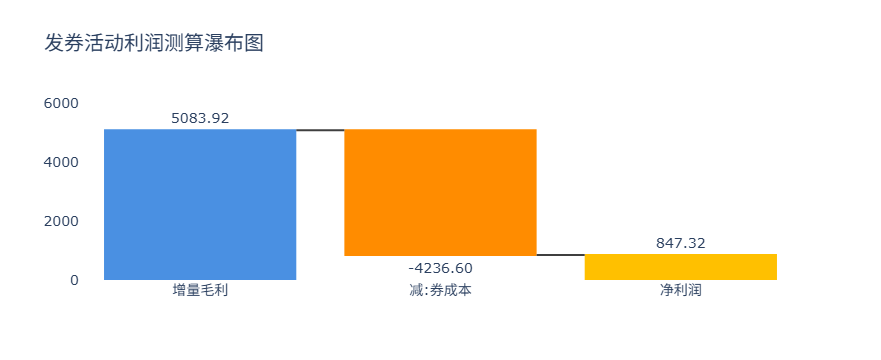

In [34]:
#利润测算瀑布图
categories = ['增量毛利', '减:券成本', '净利润']
values = [5083.92, -4236.60, 847.32]
measures = ['relative', 'relative', 'total']

fig = go.Figure(go.Waterfall(
    name = '利润测算',
    orientation = 'v',
    measure = measures,
    x = categories,
    y = values,
    textposition = 'outside',
    text = ['5083.92', '-4236.60', '847.32'], 
    connector = {'line':{'color':'rgb(63, 63, 63)'}}, 
    decreasing = {'marker':{'color':'#FF8C00'}}, 
    increasing = {'marker':{'color':'#4A90E2'}}, 
    totals = {'marker':{'color':'#FFC000'}}  
))


fig.update_layout(
    title = '发券活动利润测算瀑布图',
    showlegend = False,
    plot_bgcolor='white',
    font=dict(size=14)
)

fig.show()

## 2.ROI敏感性分析

In [35]:
cr_list = np.arange(0.30, 0.66, 0.05)   # 挽回率 30%~65%
coupon_list = [5, 10, 15, 20]               # 券面额（元）

def roi_of(cr, coupon):
    saved = redeem_n * cr                            
    gross = saved * TARGET_AOV * GROSS_MARGIN      
    cost  = redeem_n * coupon              
    return (gross - cost) / cost         

roi_M = np.array([[roi_of(cr, c) for c in coupon_list] for cr in cr_list])
roi_df = pd.DataFrame(roi_M,
                      index=[f"{c:.0%}" for c in cr_list],
                      columns=[f"{c}元" for c in coupon_list])
print("===== ROI敏感性矩阵（行=挽回率，列=券面额）=====")
print(roi_df.round(3))
roi_df.to_csv("ROI敏感性矩阵_挽回率x面额.csv", encoding="utf-8-sig")

===== ROI敏感性矩阵（行=挽回率，列=券面额）=====
       5元   10元   15元   20元
30%  0.44 -0.28 -0.52 -0.64
35%  0.68 -0.16 -0.44 -0.58
40%  0.92 -0.04 -0.36 -0.52
45%  1.16  0.08 -0.28 -0.46
50%  1.40  0.20 -0.20 -0.40
55%  1.64  0.32 -0.12 -0.34
60%  1.88  0.44 -0.04 -0.28
65%  2.12  0.56  0.04 -0.22


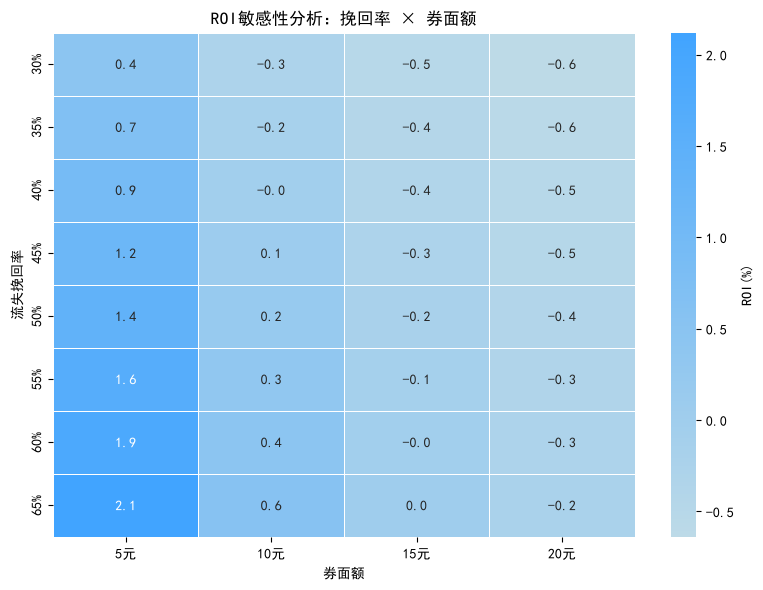

In [36]:
#敏感性分析热力图
color_list = ["#FFF7DB", "#41A4FF"]
custom_cmap = LinearSegmentedColormap.from_list("roi_cmap", color_list, N=200)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(roi_df, 
            annot=True, 
            fmt='.1f',  
            cmap=custom_cmap,
            center=0, 
            linewidths=.6,  
            cbar_kws={'label': 'ROI(%)'}, 
            ax=ax)

ax.set_xlabel("券面额")
ax.set_ylabel("流失挽回率")
ax.set_title("ROI敏感性分析：挽回率 × 券面额")
plt.tight_layout()
plt.show()

## 3.方案稳健性分析

### 龙卷风图：各因素对ROI的影响幅度排序

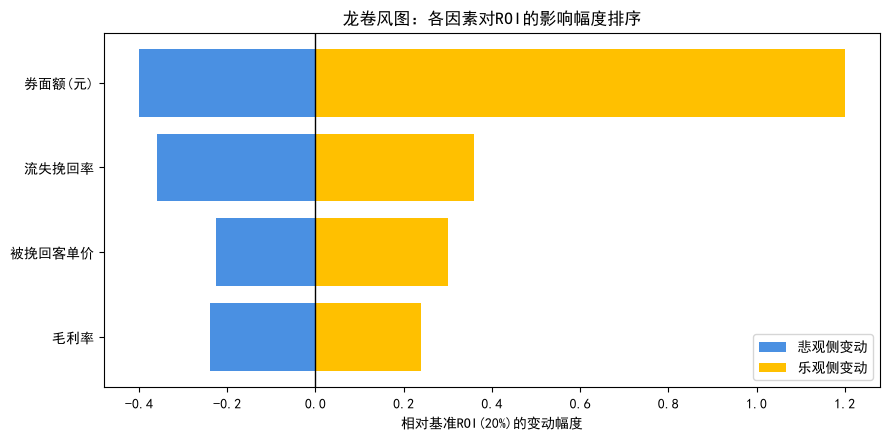

          悲观侧   乐观侧
毛利率    -0.240  0.24
被挽回客单价 -0.225  0.30
流失挽回率  -0.360  0.36
券面额(元) -0.400  1.20


In [37]:
def roi_of(cr, aov, gm, coupon):
    return cr * aov * gm / coupon - 1
    
base = dict(cr=0.50, aov=160, gm=0.15, coupon=10) #以假设的参数为基准
base_roi = roi_of(**base)

ranges = {
    '流失挽回率': ('cr', 0.35, 0.65),
    '被挽回客单价': ('aov', 130, 200),
    '毛利率': ('gm', 0.12, 0.18),
    '券面额(元)': ('coupon', 15, 5),
}

torn = {}
for name, (key, lo, hi) in ranges.items():
    p_lo, p_hi = base.copy(), base.copy()
    p_lo[key], p_hi[key] = lo, hi
    torn[name] = (roi_of(**p_lo) - base_roi, roi_of(**p_hi) - base_roi)

torn_df = pd.DataFrame(torn, index=['悲观侧', '乐观侧']).T
torn_df = torn_df.reindex(torn_df.abs().sum(axis=1).sort_values().index) 

fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(torn_df))
ax.barh(y, torn_df['悲观侧'], color='#4A90E2', label="悲观侧变动")
ax.barh(y, torn_df['乐观侧'], color='#FFC000', label="乐观侧变动")
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y); ax.set_yticklabels(torn_df.index)
ax.set_xlabel(f'相对基准ROI({base_roi:.0%})的变动幅度')
ax.set_title('龙卷风图：各因素对ROI的影响幅度排序')
ax.legend(); plt.tight_layout()
plt.show()
print(torn_df.round(3))

### 圈选比例权衡图

In [38]:
# 重建第二级合格池（聚类2/3 且 客单价≥67）
s2 = user_cluster[user_cluster['cluster'].isin([2, 3])]
s2 = s2[s2['avg_order_value'] >= 67]
pool = len(s2)

ratios = [0.1, 0.2, 0.3, 0.5, 1.0]
rows = []
for r in ratios:
    n = pool * r       
    redeem = n * 0.06   
    saved  = redeem * 0.50  
    gross  = saved * 160 * 0.15
    cost   = redeem * 10 
    net    = gross - cost  
    rows.append([f"Top{int(r*100)}%", round(n), round(cost), round(net), net/cost])
scale_df = pd.DataFrame(rows, columns=["圈选比例", "发券人数", "券预算", "净利润", "ROI"])
print(scale_df)

      圈选比例   发券人数    券预算   净利润  ROI
0   Top10%   2351   1410   282  0.2
1   Top20%   4701   2821   564  0.2
2   Top30%   7052   4231   846  0.2
3   Top50%  11753   7052  1410  0.2
4  Top100%  23506  14104  2821  0.2


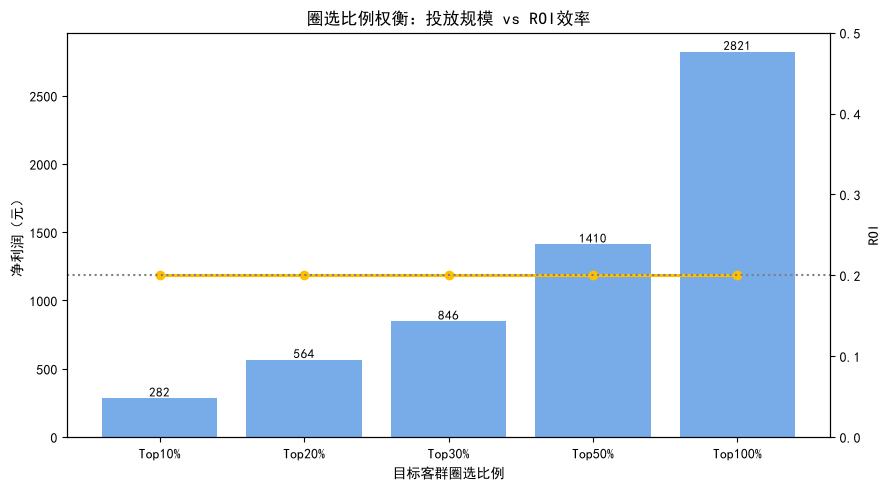

In [39]:
# 双轴图
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(scale_df["圈选比例"], scale_df["净利润"], color="#4A90E2", alpha=.75, label="净利润(元)")
ax1.set_xlabel("目标客群圈选比例"); ax1.set_ylabel("净利润（元）")
for i, v in enumerate(scale_df["净利润"]):
    ax1.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
ax2 = ax1.twinx()
ax2.plot(scale_df["圈选比例"], scale_df["ROI"], color="#FFC000", marker="o", lw=2.2, label="ROI")
ax2.set_ylabel("ROI"); ax2.set_ylim(0, 0.5); ax2.axhline(0.2, ls=":", c="gray")
ax1.set_title("圈选比例权衡：投放规模 vs ROI效率")
plt.tight_layout(); plt.savefig("圈选比例权衡图.png", dpi=300); plt.show()

## 券面额与流失挽回率是ROI的两大主导因素：面额越大、盈亏平衡所需挽回率越高、越易亏损；<br>基准方案"10元券+50%挽回率"对应ROI=20%，只需41.7%挽回率即可回本、留有安全边际。<br>因此券型上克制选择满100减10（不盲目加大面额），业务上依靠XGBoost精准圈选高价值高风险用户来守住挽回率，方案在合理参数波动区间内稳健可行。
